In [2]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

OUT_DIR = r"C:\Users\user\Desktop\ai causal\causal_project\african_american\smoking_status"

X_pc_full = np.load(OUT_DIR + r"\pc_input.npy")
with open(OUT_DIR + r"\pc_col_names.json") as f:
    col_names = json.load(f)

n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")
print("Input shape:", X_pc_full.shape)
print("n_nodes:", n_nodes)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (3348, 89)
n_nodes: 89


Depth=12, working on node 88: 100%|██████████| 89/89 [00:00<00:00, 2216.38it/s]


Completed in 13.5s
Nodes: 89


In [3]:
import networkx as nx
import pandas as pd

adj = cg.G.graph

edges_directed = []
edges_undirected = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names[i], col_names[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names[j], col_names[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names[i], col_names[j]))

print(f"Directed edges: {len(edges_directed)}")
print(f"Undirected edges: {len(edges_undirected)}")
print(f"Reverse edges: {len([(u,v) for u,v in edges_directed if u=='smoking_status'])}")

# build full graph for reachability
G = nx.DiGraph()
G.add_nodes_from(col_names)
for u, v in edges_directed:
    G.add_edge(u, v)
G_reach = G.copy()
for u, v in edges_undirected:
    G_reach.add_edge(u, v)
    G_reach.add_edge(v, u)

# ancestral subgraph
ancestors = nx.ancestors(G_reach, "smoking_status")
ancestors.add("smoking_status")
print(f"\nAncestral subgraph nodes: {len(ancestors)}")

# classify nodes
direct_parents = [u for u, v in edges_directed
                  if v == "smoking_status" and u in ancestors]
undirected_to_outcome = [u for u, v in edges_undirected
                         if v == "smoking_status" and u in ancestors] + \
                        [v for u, v in edges_undirected
                         if u == "smoking_status" and v in ancestors]

upstream_hubs = [n for n in ancestors
                 if n != "smoking_status"
                 and n not in direct_parents
                 and n not in undirected_to_outcome]

print(f"\nDirect Parents (red): {len(direct_parents)}")
for p in direct_parents:
    print(f"  {p[:40]}")
print(f"\nUpstream Hubs (blue): {len(upstream_hubs)}")
for h in upstream_hubs:
    print(f"  {h[:40]}")
print(f"\nUndirected to outcome: {len(undirected_to_outcome)}")

Directed edges: 43
Undirected edges: 13
Reverse edges: 0

Ancestral subgraph nodes: 23

Direct Parents (red): 13
  exm100944-0_B_R_1921482882
  exm2224359-0_B_F_1960100656
  exm1245580-0_B_F_2060131617
  exm1379120-0_T_F_1921625489
  exm1421650-0_T_F_1923324725
  exm236098-0_T_R_1918982506
  exm243224-0_B_R_1919004432
  exm-rs16982520-131_T_F_1990489099
  exm317474-0_B_F_1922239353
  exm418184-0_B_R_1923021066
  exm609218-0_B_F_1918575531
  exm759751-0_T_R_1922412944
  exm782555-0_B_R_1922302526

Upstream Hubs (blue): 9
  exm1597603-0_T_R_2060425485
  exm566503-0_B_F_1921959011
  exm777999-0_B_F_1922426645
  exm672948-0_T_R_1918439710
  exm337953-0_B_F_1922244919
  exm1214458-0_T_F_1921678495
  exm61019-0_T_R_1919145850
  exm283605-0_T_R_1919013716
  exm2249651-0_B_R_1975240842

Undirected to outcome: 0


In [4]:
import requests
import time
import re

MANIFEST = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(MANIFEST, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
chr_lookup = manifest_df.set_index("core_name")["Chr"]
pos_lookup_m = manifest_df.set_index("core_name")["MapInfo"]

def get_chr(pid):
    if pid == "smoking_status": return "phenotype"
    return str(chr_lookup.get(re.sub(r'_\d+$', '', pid), "?"))

def get_pos(pid):
    val = pos_lookup_m.get(re.sub(r'_\d+$', '', pid), None)
    return int(val) if pd.notna(val) else None

def get_gene_ensembl(chrom, pos, window=50000):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos-window}-{pos+window}"
    params = {"feature": "gene", "content-type": "application/json"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200: return "?"
        genes = r.json()
        if not genes: return "intergenic"
        coding = [g for g in genes if g.get("biotype") == "protein_coding"]
        targets = coding if coding else genes
        names = list(set(g.get("external_name", "?") for g in targets))
        return " | ".join(names[:2])
    except: return "?"

all_network_snps = direct_parents + upstream_hubs
print("Annotating", len(all_network_snps), "SNPs...")
gene_map = {}
for pid in all_network_snps:
    chrom = get_chr(pid)
    pos = get_pos(pid)
    gene = get_gene_ensembl(chrom, pos)
    gene_map[pid] = gene
    print(f"  Chr{chrom}:{pos:,} → {gene}")
    time.sleep(0.5)

Annotating 22 SNPs...
  Chr1:152,329,460 → FLG2 | FLG
  Chr16:20,435,321 → PDILT | ACSM2A
  Chr16:58,320,066 → CCDC113 | GINS3
  Chr18:21,530,071 → TTC39C | LAMA3
  Chr19:9,074,017 → MUC16
  Chr2:160,889,476 → PLA2R1
  Chr2:175,436,940 → WIPF1
  Chr20:57,758,720 → ZNF831
  Chr3:50,312,822 → NAT6 | HYAL3
  Chr4:110,394,162 → SEC24B
  Chr7:22,985,282 → FAM126A
  Chr9:90,584,110 → CDK20
  Chr9:130,206,472 → SLC2A8 | ZNF79
  Chr22:29,533,437 → KREMEN1
  Chr6:90,572,081 → GJA10 | MDN1
  Chr9:123,914,765 → RAB14 | CNTRL
  Chr7:150,934,650 → ABCF2 | ASB10
  Chr3:112,736,411 → CD200R1 | GTPBP8
  Chr16:4,812,705 → SEPT12 | ANKS3
  Chr1:54,476,084 → TMEM59 | TCEANC2
  Chr2:242,065,944 → PPP1R7 | PASK
  Chr11:126,203,911 → RP11-712L6.5 | TIRAP


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import os

def sunflower_layout_strict(center, inner_nodes, outer_nodes):
    """Strict concentric circles — no spring distortion"""
    pos = {center: np.array([0.0, 0.0])}
    
    # inner ring — evenly spaced, start from top
    n_inner = len(inner_nodes)
    for i, node in enumerate(inner_nodes):
        angle = 2 * np.pi * i / n_inner - np.pi/2
        pos[node] = np.array([2.0 * np.cos(angle), 2.0 * np.sin(angle)])
    
    # outer ring — evenly spaced, offset by half step from inner
    n_outer = len(outer_nodes)
    offset = np.pi / n_outer  # half step offset so outer nodes sit between inner ones
    for i, node in enumerate(outer_nodes):
        angle = 2 * np.pi * i / n_outer - np.pi/2 + offset
        pos[node] = np.array([3.8 * np.cos(angle), 3.8 * np.sin(angle)])
    
    return pos

pos = sunflower_layout_strict("smoking_status", direct_parents, upstream_hubs)

# node properties
node_colors = []
node_sizes = []
for node in G_final.nodes():
    if node == "smoking_status":
        node_colors.append("#F4D03F")
        node_sizes.append(5000)
    elif node in direct_parents:
        node_colors.append("#E74C3C")
        node_sizes.append(2200)
    else:
        node_colors.append("#2980B9")
        node_sizes.append(2000)

node_labels = {n: make_label(n) for n in G_final.nodes()}

# separate edge types
directed_to_outcome = [(u,v) for u,v in edges_directed
                       if v == "smoking_status" and u in ancestors]
directed_snp_snp = [(u,v) for u,v in edges_directed
                    if v != "smoking_status" and u in ancestors and v in ancestors]

fig, ax = plt.subplots(figsize=(20, 20))

# draw nodes
nx.draw_networkx_nodes(G_final, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.93, ax=ax)
nx.draw_networkx_labels(G_final, pos, labels=node_labels,
                        font_size=7, font_weight="bold", ax=ax)

# SNP → smoking_status edges (solid gray, straight)
nx.draw_networkx_edges(G_final, pos,
                       edgelist=directed_to_outcome,
                       edge_color="dimgray", arrows=True,
                       arrowsize=25, width=2.0,
                       ax=ax)

# SNP → SNP directed edges (solid gray, curved)
nx.draw_networkx_edges(G_final, pos,
                       edgelist=directed_snp_snp,
                       edge_color="#7F8C8D", arrows=True,
                       arrowsize=18, width=1.2,
                       connectionstyle="arc3,rad=0.2",
                       ax=ax)

# undirected edges (dashed blue)
nx.draw_networkx_edges(G_final, pos,
                       edgelist=undirected_draw,
                       edge_color="#2980B9", arrows=False,
                       style="dashed", width=1.2,
                       connectionstyle="arc3,rad=0.2",
                       ax=ax)

# legend
legend_elements = [
    mpatches.Patch(color="#F4D03F", label="Target Phenotype"),
    mpatches.Patch(color="#E74C3C", label="Direct Parents (High Specificity)"),
    mpatches.Patch(color="#2980B9", label="Upstream Hubs (High Pleiotropy)"),
    plt.Line2D([0],[0], color="dimgray", linewidth=2, label="SNP → Phenotype"),
    plt.Line2D([0],[0], color="#7F8C8D", linewidth=1.5, label="SNP → SNP (directed)"),
    plt.Line2D([0],[0], color="#2980B9", linewidth=1.5,
               linestyle="dashed", label="SNP — SNP (undirected)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10,
          framealpha=0.9, bbox_to_anchor=(0.0, 1.0))

ax.set_title("Causal Architecture: Smoking Status\n"
             "African-American Cohort (GSE148375) | DoubleML + PC Algorithm",
             fontsize=15, fontweight="bold")
ax.axis("off")
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.set_aspect("equal")
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "sunflower_v2_smoking_status_AA.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

NameError: name 'G_final' is not defined

Depth=12, working on node 88: 100%|██████████| 89/89 [00:00<00:00, 2156.45it/s]


PC completed in 13.3s
Directed: 43, Undirected: 13
Direct Parents: 13
Upstream Hubs: 9


C:\Users\user\AppData\Local\Temp\ipykernel_114360\4252120164.py:206: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G_final, pos, edgelist=[(u,v)],


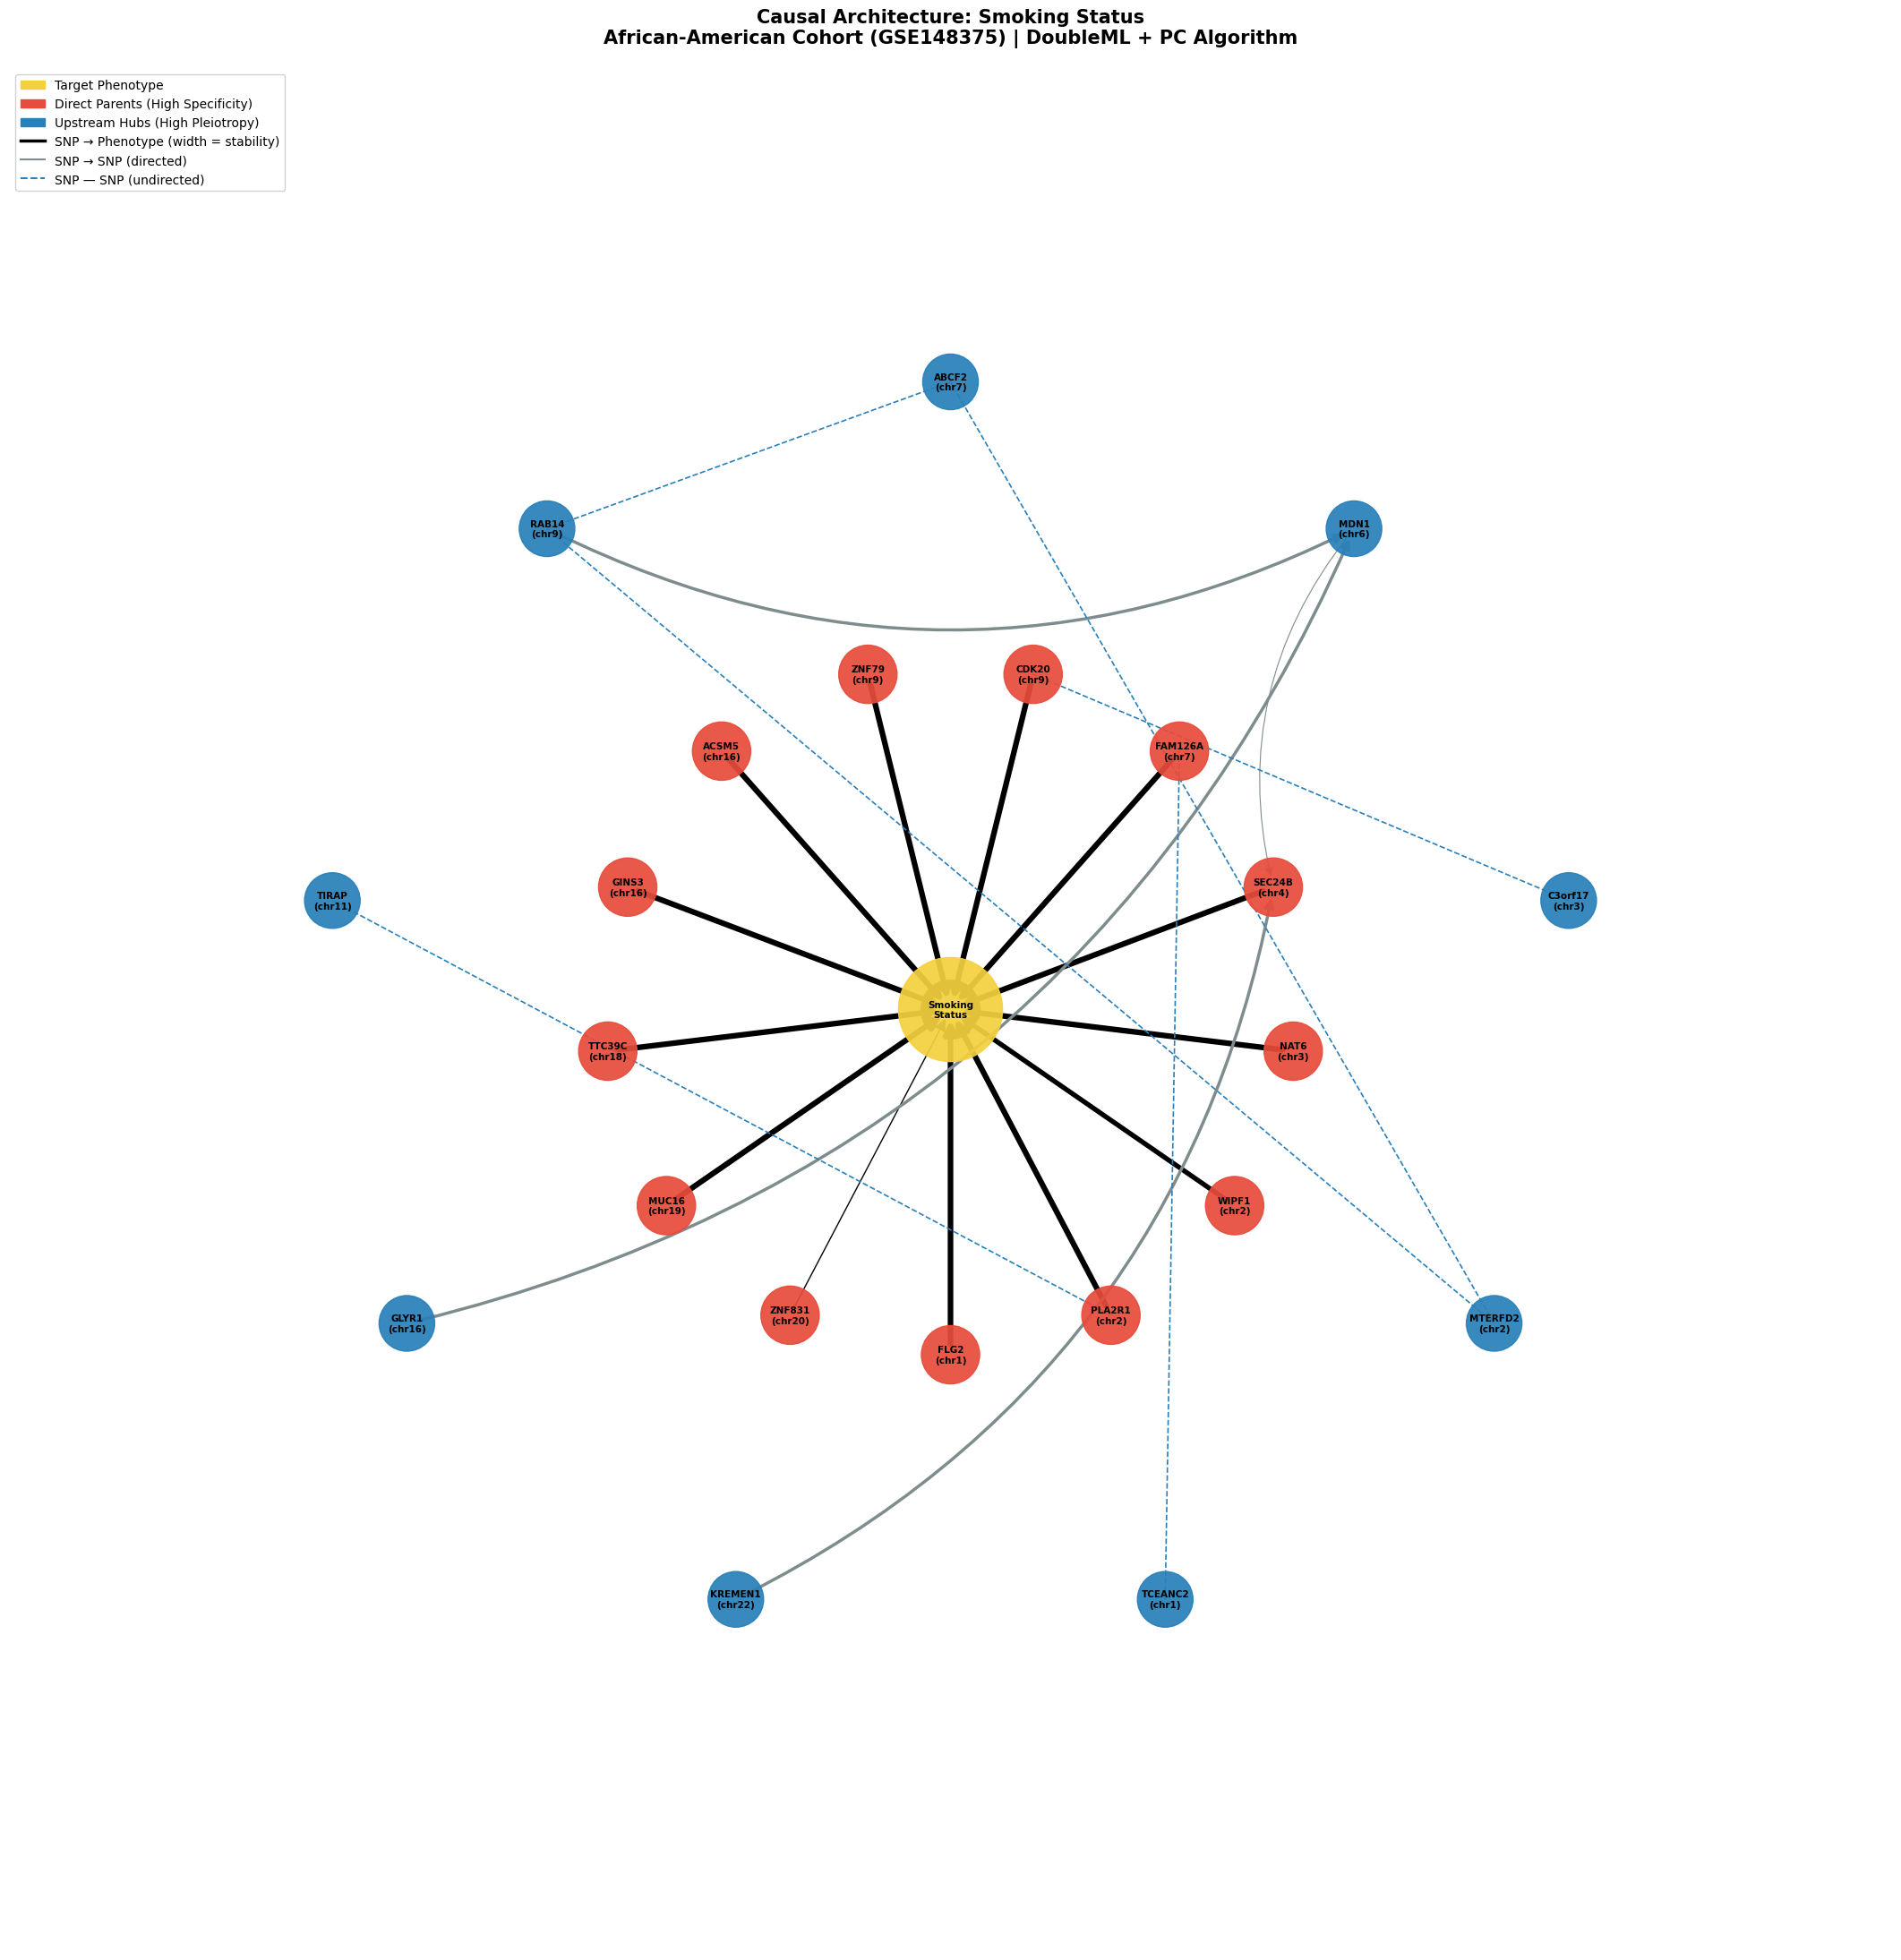

Saved: C:\Users\user\Desktop\ai causal\causal_project\african_american\smoking_status\sunflower_v3_smoking_status_AA.png


In [7]:
import numpy as np
import json
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

OUT_DIR = r"C:\Users\user\Desktop\ai causal\causal_project\african_american\smoking_status"
MANIFEST = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"

# load inputs
X_pc_full = np.load(OUT_DIR + r"\pc_input.npy")
with open(OUT_DIR + r"\pc_col_names.json") as f:
    col_names = json.load(f)

n_nodes = len(col_names)
outcome_idx = col_names.index("smoking_status")

# run PC algorithm
bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[outcome_idx], 1)

start = time.time()
cg = pc(data=X_pc_full, alpha=0.001, indep_test=fisherz, stable=True,
        uc_rule=0, uc_priority=2, background_knowledge=bk,
        verbose=False, show_progress=True, node_names=col_names)
print(f"PC completed in {time.time()-start:.1f}s")

# extract edges
adj = cg.G.graph
edges_directed = []
edges_undirected = []
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names[i], col_names[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names[j], col_names[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names[i], col_names[j]))

print(f"Directed: {len(edges_directed)}, Undirected: {len(edges_undirected)}")

# ancestral subgraph
G = nx.DiGraph()
G.add_nodes_from(col_names)
for u, v in edges_directed:
    G.add_edge(u, v)
G_reach = G.copy()
for u, v in edges_undirected:
    G_reach.add_edge(u, v)
    G_reach.add_edge(v, u)

ancestors = nx.ancestors(G_reach, "smoking_status")
ancestors.add("smoking_status")

direct_parents = [u for u, v in edges_directed
                  if v == "smoking_status" and u in ancestors]
upstream_hubs = [n for n in ancestors
                 if n != "smoking_status" and n not in direct_parents]

print(f"Direct Parents: {len(direct_parents)}")
print(f"Upstream Hubs: {len(upstream_hubs)}")

# build final graph
G_final = nx.DiGraph()
G_final.add_nodes_from(ancestors)
for u, v in edges_directed:
    if u in ancestors and v in ancestors:
        G_final.add_edge(u, v)

undirected_draw = []
undirected_pairs = set()
for u, v in edges_undirected:
    if u in ancestors and v in ancestors and (v,u) not in undirected_pairs:
        undirected_pairs.add((u,v))
        undirected_draw.append((u,v))

# manifest for chromosome lookup
manifest_df = pd.read_csv(MANIFEST, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
chr_lookup = manifest_df.set_index("core_name")["Chr"]

def get_chr(pid):
    if pid == "smoking_status": return "phenotype"
    return str(chr_lookup.get(re.sub(r'_\d+$', '', pid), "?"))

# gene map from previous annotation run
gene_map = {
    "exm100944-0_B_R_1921482882": "FLG2 | FLG",
    "exm2224359-0_B_F_1960100656": "ACSM5 | ACSM2A",
    "exm1245580-0_B_F_2060131617": "GINS3 | PRSS54",
    "exm1379120-0_T_F_1921625489": "TTC39C | LAMA3",
    "exm1421650-0_T_F_1923324725": "MUC16",
    "exm236098-0_T_R_1918982506": "PLA2R1",
    "exm243224-0_B_R_1919004432": "WIPF1",
    "exm-rs16982520-131_T_F_1990489099": "ZNF831",
    "exm317474-0_B_F_1922239353": "NAT6 | HYAL3",
    "exm418184-0_B_R_1923021066": "SEC24B",
    "exm609218-0_B_F_1918575531": "FAM126A",
    "exm759751-0_T_R_1922412944": "CDK20",
    "exm782555-0_B_R_1922302526": "ZNF79 | RPL12",
    "exm283605-0_T_R_1919013716": "MTERFD2 | PASK",
    "exm777999-0_B_F_1922426645": "RAB14 | CNTRL",
    "exm672948-0_T_R_1918439710": "ABCF2 | CHPF2",
    "exm337953-0_B_F_1922244919": "C3orf17 | GTPBP8",
    "exm1214458-0_T_F_1921678495": "GLYR1 | ZNF500",
    "exm2249651-0_B_R_1975240842": "TIRAP | DCPS",
    "exm1597603-0_T_R_2060425485": "KREMEN1",
    "exm566503-0_B_F_1921959011": "MDN1 | GJA10",
    "exm61019-0_T_R_1919145850": "TCEANC2 | LRRC42",
}

# stability map for edge width
stability_df = pd.read_csv(r"C:\Users\user\Downloads\GSE148375_clean\v2_stability_results.csv")
stability_map = dict(zip(stability_df["probe_id"], stability_df["stability_fraction"]))

def get_edge_width(u, min_w=1.0, max_w=4.5):
    stab = stability_map.get(u, 0.8)
    return min_w + (max_w - min_w) * (stab - 0.8) / 0.2

def make_label(pid):
    if pid == "smoking_status": return "Smoking\nStatus"
    gene = gene_map.get(pid, "")
    chrom = get_chr(pid)
    if gene and gene not in ["?", "intergenic"]:
        first = gene.split("|")[0].strip()
        return f"{first}\n(chr{chrom})"
    return f"(chr{chrom})\n{pid.split('-')[0]}"

def chr_sort_key(pid):
    c = get_chr(pid)
    try: return int(c)
    except: return 99

# layout
def sunflower_layout(center, inner_nodes, outer_nodes):
    pos = {center: np.array([0.0, 0.0])}
    inner_sorted = sorted(inner_nodes, key=chr_sort_key)
    outer_sorted = sorted(outer_nodes, key=chr_sort_key)
    n_inner = len(inner_sorted)
    for i, node in enumerate(inner_sorted):
        angle = 2 * np.pi * i / n_inner - np.pi/2
        pos[node] = np.array([2.2 * np.cos(angle), 2.2 * np.sin(angle)])
    n_outer = len(outer_sorted)
    offset = np.pi / max(n_outer, 1)
    for i, node in enumerate(outer_sorted):
        angle = 2 * np.pi * i / n_outer - np.pi/2 + offset
        pos[node] = np.array([4.0 * np.cos(angle), 4.0 * np.sin(angle)])
    return pos

pos = sunflower_layout("smoking_status", direct_parents, upstream_hubs)

# colors and sizes
node_colors = []
node_sizes = []
for node in G_final.nodes():
    if node == "smoking_status":
        node_colors.append("#F4D03F")
        node_sizes.append(7000)
    elif node in direct_parents:
        node_colors.append("#E74C3C")
        node_sizes.append(2200)
    else:
        node_colors.append("#2980B9")
        node_sizes.append(2000)

node_labels = {n: make_label(n) for n in G_final.nodes()}

directed_to_outcome = [(u,v) for u,v in edges_directed
                       if v == "smoking_status" and u in ancestors]
directed_snp_snp = [(u,v) for u,v in edges_directed
                    if v != "smoking_status" and u in ancestors and v in ancestors]

# draw
fig, ax = plt.subplots(figsize=(22, 22))
nx.draw_networkx_nodes(G_final, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.93, ax=ax)
nx.draw_networkx_labels(G_final, pos, labels=node_labels,
                        font_size=7.5, font_weight="bold", ax=ax)

for u, v in directed_to_outcome:
    w = get_edge_width(u)
    nx.draw_networkx_edges(G_final, pos, edgelist=[(u,v)],
                           edge_color="black", arrows=True,
                           arrowsize=20, width=w, ax=ax)

for u, v in directed_snp_snp:
    w = get_edge_width(u, min_w=0.8, max_w=2.5)
    nx.draw_networkx_edges(G_final, pos, edgelist=[(u,v)],
                           edge_color="#7F8C8D", arrows=True,
                           arrowsize=15, width=w,
                           connectionstyle="arc3,rad=0.25", ax=ax)

for u, v in undirected_draw:
    nx.draw_networkx_edges(G_final, pos, edgelist=[(u,v)],
                           edge_color="#2980B9", arrows=False,
                           style="dashed", width=1.2,
                           connectionstyle="arc3,rad=0.3", ax=ax)

legend_elements = [
    mpatches.Patch(color="#F4D03F", label="Target Phenotype"),
    mpatches.Patch(color="#E74C3C", label="Direct Parents (High Specificity)"),
    mpatches.Patch(color="#2980B9", label="Upstream Hubs (High Pleiotropy)"),
    plt.Line2D([0],[0], color="black", linewidth=2.5,
               label="SNP → Phenotype (width = stability)"),
    plt.Line2D([0],[0], color="#7F8C8D", linewidth=1.5, label="SNP → SNP (directed)"),
    plt.Line2D([0],[0], color="#2980B9", linewidth=1.5,
               linestyle="dashed", label="SNP — SNP (undirected)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=10,
          framealpha=0.9, bbox_to_anchor=(0.0, 1.0))

ax.set_title("Causal Architecture: Smoking Status\n"
             "African-American Cohort (GSE148375) | DoubleML + PC Algorithm",
             fontsize=15, fontweight="bold", pad=20)
ax.axis("off")
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
plt.tight_layout()

out_path = os.path.join(OUT_DIR, "sunflower_v3_smoking_status_AA.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)